#### Time Series Decomposition

It is a very important aspect in time series data analysis.

It helps in teaching

    (a.)    Trends

    (b.)    Seasonality

    (c.)    Residuals


Suppose the sales data increases every year and in the month of december, it will increase more rapidly

    (a.)   Trends ===========>  Trends more even more increase.

    (b.)   Seasonality =======>  Repeated patterns will appear every year.

    (c.)    Residuals ========>  Rando noise will also increase.


#### Problem Statement

1.  The main objective of this problem statement is to perform the time series decomposition on the sales data and divide it into three parts :---------------------

    (a.)    Trneds

    (b.)    Seasonality

    (c.)    Residuals

2.  The above 3 parts are the decomposed section of the sales data obtained due to the time series decomposition.

#### Step 1: Import all the necessary libraries

In [390]:
import      numpy                           as      np
import      pandas                          as      pd
import      matplotlib.pyplot               as      plt
import      seaborn                         as      sns

from        statsmodels.tsa.seasonal        import  seasonal_decompose

#### OBSERVATIONS:

1.  pandas =======================>   Creation of dataframe

2.  numpy   ======================>   performing mathematical calculation

3.  matplotlib ===================>  performing data visualizations

4.  seaborn   ====================>  perform data correlation

5.  seasonal_decompose ===========>  used for performing the decomposition on the time series data

#### Step 2: Load the dataset

In [391]:
df = pd.read_csv('AirPassengers.csv')

In [392]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


#### OBSERVATIONS:

1.  The above AirPassengers dataset contains the monthly airline passengers at the starting date of each month beginning from 1949 till 1960.

2.  This dataset is very useful for time series learning.

#### Step 3: Perform Data Exploration

In [393]:
#### get the first five rows of the dataset

df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [394]:
#### get the last five rows of the dataset

df.tail()

,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [395]:
#### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 144


In [396]:
#### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (144, 2)


In [397]:
#### get the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


#### OBSERVATIONS:

1.  The date column is string in nature.

2.  The value is integer in nature.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [398]:
#### Convert the string form of date to  datetime

df['date'] = pd.to_datetime(df['date'])

In [399]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [400]:
#### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 144


In [401]:
#### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (144, 2)


In [402]:
#### get the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[ns]
 1   value   144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


#### OBSERVATIONS:

1.  The date column has been converted from object type to datetime type.

In [403]:
#### set the date column as an index

df.set_index('date', inplace=True)

In [404]:
df

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


#### OBSERVATIONS:

1.  The date column has been made as an index.

In [405]:
#### To check for the NULL records in the dataset

df.isnull().sum()

value    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [406]:
#### Rename the column "value" to "Passengers" in dataset

df.rename(columns={'value':'Passengers'},inplace=True)

In [407]:
df

,Passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


#### OBSERVATIONS:

1.  The column name 'value' has been renamed to 'Passengers' in the dataset.

#### Step 5: Plot the Original Time Series data

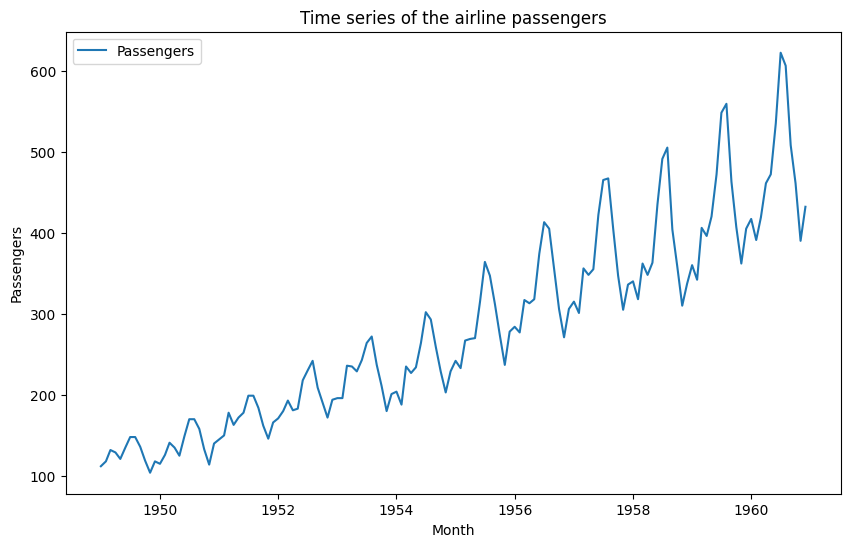

In [408]:
plt.figure(figsize=(10,6))

#### plot the time series data
plt.plot(df.index, df['Passengers'], label = 'Passengers')

#### give the title of the graph
plt.title('Time series of the airline passengers')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above dataset depicts the time series of the airline passengers for the starting date of each and every month beginning from 1949 till 1960.

2.  The above dataset shows the following things :-----------------

    (a.)    There is an upward trend in the dataset ranging from 1949 till 1960 and the number of airline passengers increases each and every year.

    (b.)    There is seasonality in the time series dataset and there is repeated seasonal patterns shown each and every year.

    (c.)    There is a lot of variance in the airline passengers dataset.

#### Step 6: Perform decomposition  of the rime series data

In [409]:
from    statsmodels.tsa.seasonal    import seasonal_decompose

#### create an object for seasonal decomposition

decomposition = seasonal_decompose(
    df['Passengers']                        ,
    model   =   'Multiplicative'            ,
    period  =       12
)

#### OBSERVATIONS:

1.  The object for seasonal_decompose has been created with the following parameters :--------------

    (a.)    df['Passengers']    =============>  Input data

    (b.)    model   =   'Multiplicative'    ==========>  as year increases, the number of airline passengers also increases.

    (c.)   period = 12 ============>  the airline passengers are present at the starting date for each month. so the data is monthly

        12 months = 1 seasonal cycle

#### Step 7: Extract the trends, seasonality and residuals from the time series data

In [410]:
#### Extract the trend, seasonality and residuals from the data

trend       =   decomposition.trend

seasonal    =   decomposition.seasonal

residuals   =   decomposition.resid

In [411]:
print("Trend of the time series data is:", trend)

Trend of the time series data is: date
1949-01-01   NaN
1949-02-01   NaN
1949-03-01   NaN
1949-04-01   NaN
1949-05-01   NaN
              ..
1960-08-01   NaN
1960-09-01   NaN
1960-10-01   NaN
1960-11-01   NaN
1960-12-01   NaN
Name: trend, Length: 144, dtype: float64


In [412]:
print("Seasonality of the time series data is:", seasonal)

Seasonality of the time series data is: date
1949-01-01   -24.748737
1949-02-01   -36.188131
1949-03-01    -2.241162
1949-04-01    -8.036616
1949-05-01    -4.506313
                ...    
1960-08-01    62.823232
1960-09-01    16.520202
1960-10-01   -20.642677
1960-11-01   -53.593434
1960-12-01   -28.619949
Name: seasonal, Length: 144, dtype: float64


In [413]:
print("Residuals of the time series data is:", residuals)

Residuals of the time series data is: date
1949-01-01   NaN
1949-02-01   NaN
1949-03-01   NaN
1949-04-01   NaN
1949-05-01   NaN
              ..
1960-08-01   NaN
1960-09-01   NaN
1960-10-01   NaN
1960-11-01   NaN
1960-12-01   NaN
Name: resid, Length: 144, dtype: float64


#### OBSERVATIONS:

1.  Trend represents the long term movement.

2.  Seasonality represents the repeating cycles.

3.  Residuals represents the noise.

#### Step 8: Plot the Time series data along with the decomposed parts

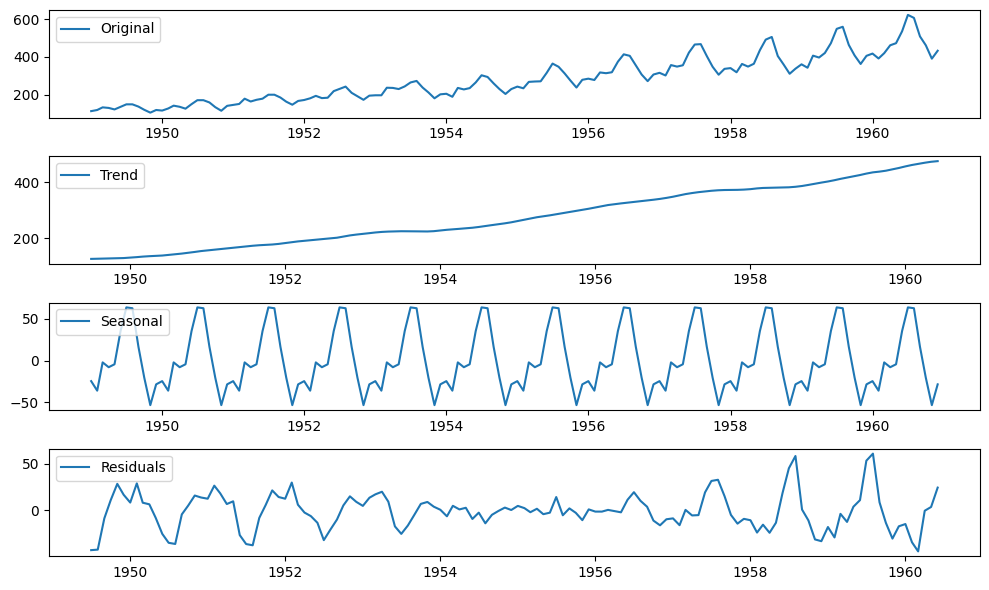

In [414]:
plt.figure(figsize=(10,6))

#### plot the original data
plt.subplot(411)
plt.plot(df['Passengers'], label = 'Original')
plt.legend(loc = 'upper left')

#### plot the trend of the time series data
plt.subplot(412)
plt.plot(trend           , label = 'Trend')
plt.legend(loc = 'upper left')


#### plot the seasonality of the time series data
plt.subplot(413)
plt.plot(seasonal        ,  label = 'Seasonal')
plt.legend(loc = 'upper left')


#### plot the residuals of the time series data
plt.subplot(414)
plt.plot(residuals       , label = 'Residuals')
plt.legend(loc = 'upper left')

plt.tight_layout()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  There are four graphs formed. They are as follows :-----

    (a.)    Original =================>

            (i) It represents the original time series.

            (ii) With the increase in the number of years, the number of airline passengers increases.


    (b.)   Trend ======================>

            (i) It represents the upward trend.

            (ii) This is because with the increase in the number of years, the number of airline passengers increases.

    (c.)   Seasonal ===================>

            (i) There is a repeating  cyclic patterns occuring every year.

    (d.)    Residuals =================>

            (i) There is a lot of noise or variations formed in the data between 1949 till 1960.


2. So the above graph represents the time sereies data as well as its decomposed components formed after the seasonal decomposition.
